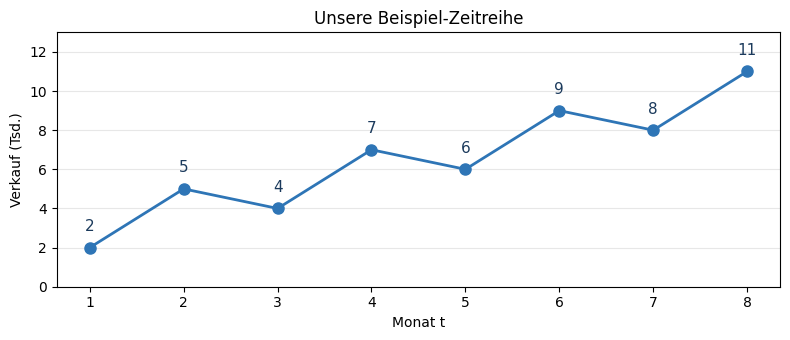

In [1]:
import matplotlib.pyplot as plt

t = range(1, 9)
x = [2, 5, 4, 7, 6, 9, 8, 11]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(t, x, 'o-', color='#2E75B6', linewidth=2, markersize=8)
for i, v in enumerate(x):
    ax.annotate(str(v), (t[i], v), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=11, color='#1B3A5C')
ax.set(xlabel='Monat t', ylabel='Verkauf (Tsd.)', title='Unsere Beispiel-Zeitreihe',
       xticks=t, ylim=(0, 13))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('block1_beispiel_zeitreihe.png', dpi=200)
plt.show()

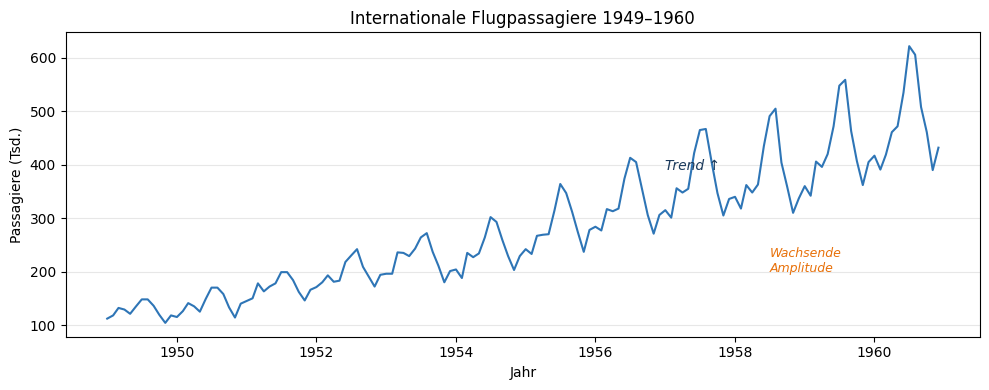

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# AirPassengers ist überall verfügbar — oder direkt inline:
#url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv("airline-passengers.csv", parse_dates=['Month'], index_col='Month')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df.index, df['Passengers'], color='#2E75B6', linewidth=1.5)
ax.set(xlabel='Jahr', ylabel='Passagiere (Tsd.)',
       title='Internationale Flugpassagiere 1949–1960')
ax.grid(axis='y', alpha=0.3)
ax.annotate('Trend ↑', xy=(pd.Timestamp('1957-01'), 390),
            fontsize=10, color='#1B3A5C', fontstyle='italic')
ax.annotate('Wachsende\nAmplitude', xy=(pd.Timestamp('1958-07'), 200),
            fontsize=9, color='#E8710A', fontstyle='italic')
plt.tight_layout()
plt.savefig('block1_airpassengers.png', dpi=200)
plt.show()

In [6]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 10.5 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


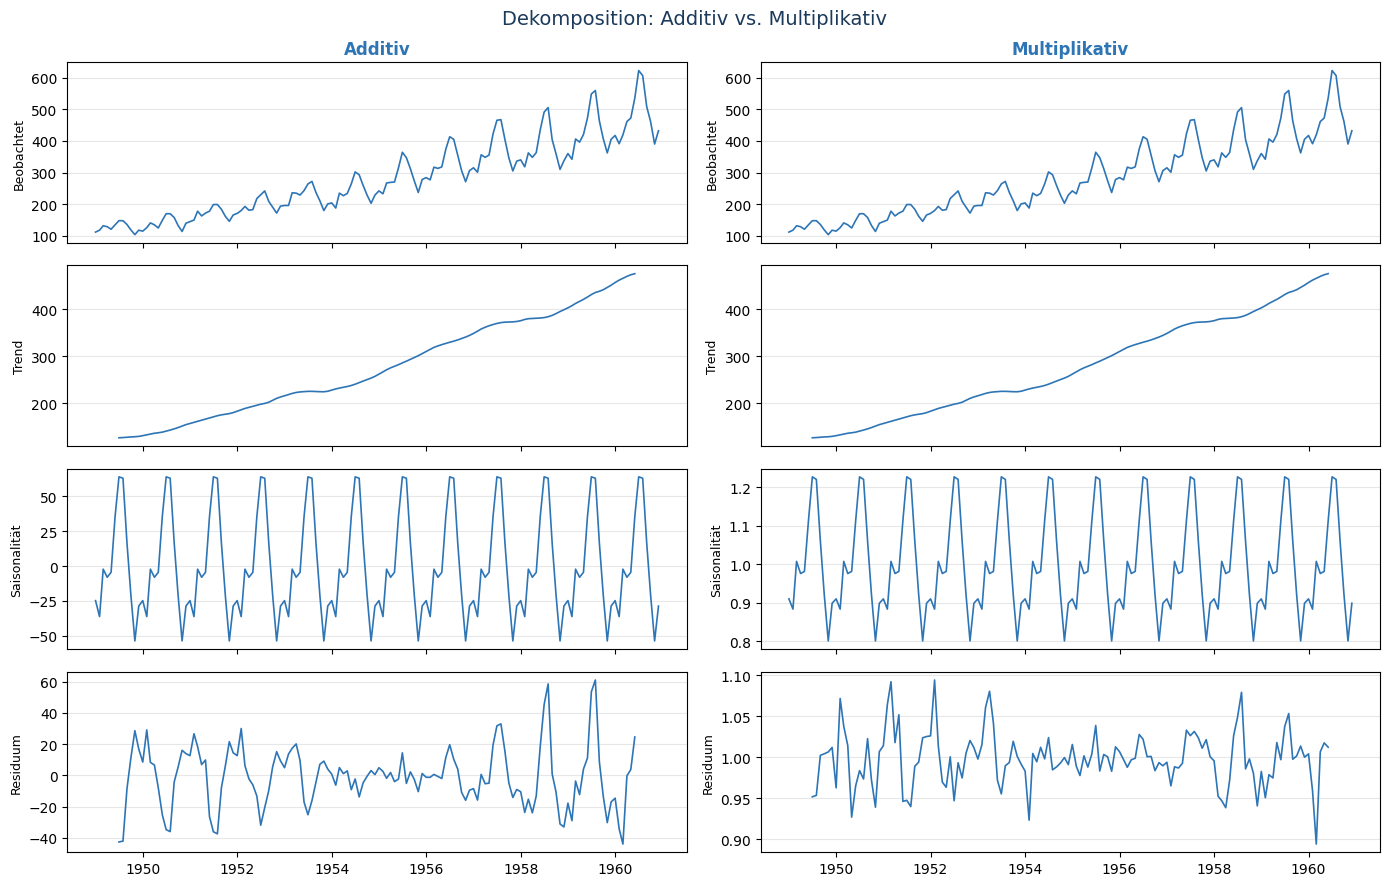

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

#url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv("airline-passengers.csv", parse_dates=['Month'], index_col='Month')
ts = df['Passengers']
ts.index.freq = 'MS'

fig, axes = plt.subplots(4, 2, figsize=(14, 9), sharex=True)
fig.suptitle('Dekomposition: Additiv vs. Multiplikativ', fontsize=14, color='#1B3A5C')

for col, (model, label) in enumerate([('additive', 'Additiv'), ('multiplicative', 'Multiplikativ')]):
    dec = seasonal_decompose(ts, model=model)
    for row, (data, name) in enumerate([
        (dec.observed, 'Beobachtet'), (dec.trend, 'Trend'),
        (dec.seasonal, 'Saisonalität'), (dec.resid, 'Residuum')
    ]):
        ax = axes[row, col]
        ax.plot(data, color='#2E75B6', linewidth=1.2)
        ax.set_ylabel(name, fontsize=9)
        if row == 0:
            ax.set_title(label, fontsize=12, color='#2E75B6', fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('block2_dekomposition_vergleich.png', dpi=200)
plt.show()

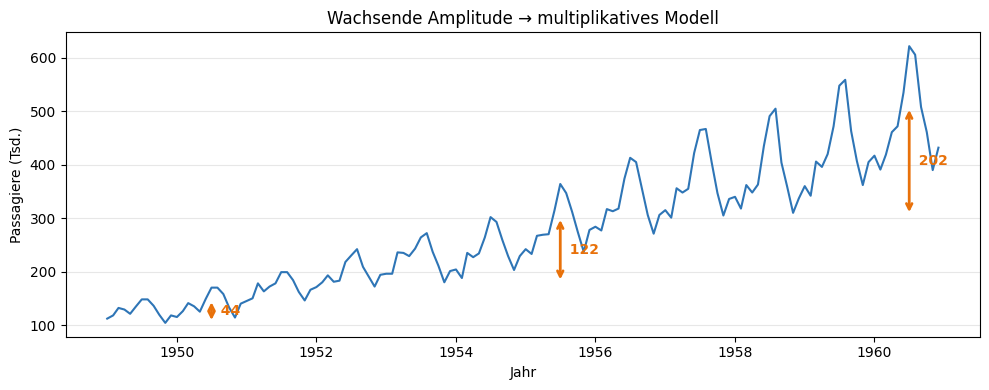

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

#url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
#df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df = pd.read_csv("airline-passengers.csv", parse_dates=['Month'], index_col='Month')

ts = df['Passengers']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts.index, ts, color='#2E75B6', linewidth=1.5)

# Amplitude-Klammern visuell markieren
for year, ymin, ymax in [(1950, 104, 148), (1955, 180, 302), (1960, 306, 508)]:
    mid = pd.Timestamp(f'{year}-07-01')
    ax.annotate('', xy=(mid, ymax), xytext=(mid, ymin),
                arrowprops=dict(arrowstyle='<->', color='#E8710A', lw=2))
    ax.text(mid, (ymin+ymax)/2, f'  {ymax-ymin}', color='#E8710A',
            fontsize=10, fontweight='bold', va='center')

ax.set(title='Wachsende Amplitude → multiplikatives Modell',
       xlabel='Jahr', ylabel='Passagiere (Tsd.)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('block2_amplitude_check.png', dpi=200)
plt.show()

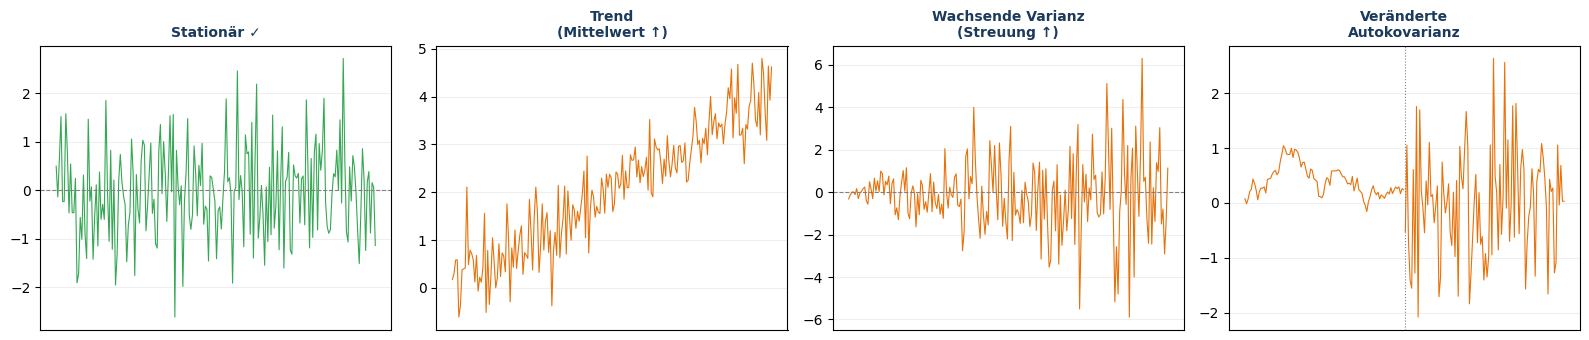

In [12]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n = 200

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
titles = ['Stationär ✓', 'Trend\n(Mittelwert ↑)', 'Wachsende Varianz\n(Streuung ↑)', 'Veränderte\nAutokovarianz']
colors = ['#34A853', '#E8710A', '#E8710A', '#E8710A']

# 1: Stationär
axes[0].plot(np.random.normal(0, 1, n), color=colors[0], lw=0.8)
axes[0].axhline(0, color='gray', ls='--', lw=0.8)

# 2: Trend (nicht-konstanter Mittelwert)
axes[1].plot(np.linspace(0, 4, n) + np.random.normal(0, 0.5, n), color=colors[1], lw=0.8)

# 3: Wachsende Varianz
axes[2].plot(np.random.normal(0, 1, n) * np.linspace(0.2, 3, n), color=colors[2], lw=0.8)
axes[2].axhline(0, color='gray', ls='--', lw=0.8)

# 4: Veränderte Autokovarianz (erst glatt, dann sprunghaft)
smooth = np.cumsum(np.random.normal(0, 0.1, n//2))
jumpy = np.random.normal(0, 1, n//2)
axes[3].plot(range(n//2), smooth, color=colors[3], lw=0.8)
axes[3].plot(range(n//2, n), jumpy, color=colors[3], lw=0.8)
axes[3].axvline(n//2, color='gray', ls=':', lw=0.8)

for ax, title, col in zip(axes, titles, colors):
    ax.set_title(title, fontsize=10, color='#1B3A5C', fontweight='bold')
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('block3_stationaritaet_vergleich.png', dpi=200)
plt.show()

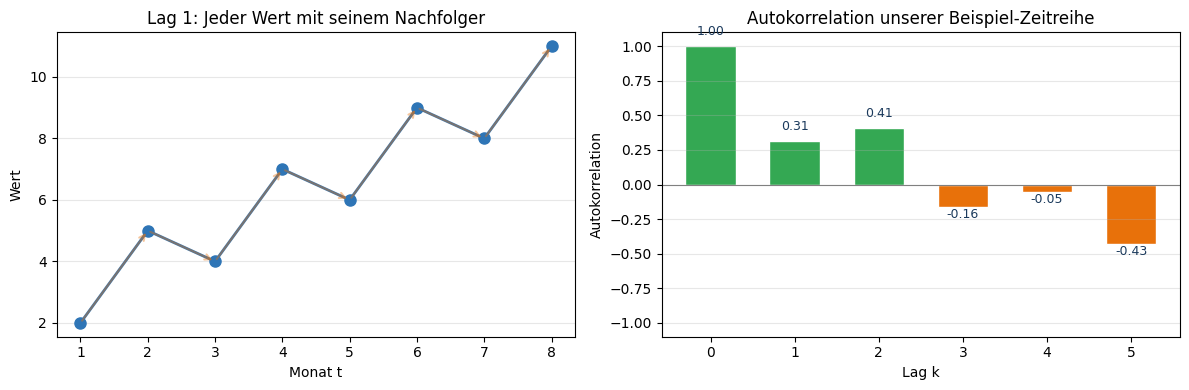

In [13]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([2, 5, 4, 7, 6, 9, 8, 11])
mean_x = x.mean()
n = len(x)

# Autokorrelation für Lags 0–5
lags = range(6)
acf = [np.sum((x[:n-k] - mean_x) * (x[k:] - mean_x)) / np.sum((x - mean_x)**2) for k in lags]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Links: Zeitreihe mit Lag-Pfeilen
ax1.plot(range(1,9), x, 'o-', color='#2E75B6', lw=2, ms=8)
for i in range(len(x)-1):
    ax1.annotate('', xy=(i+2, x[i+1]), xytext=(i+1, x[i]),
                 arrowprops=dict(arrowstyle='->', color='#E8710A', lw=1.5, alpha=0.4))
ax1.set(title='Lag 1: Jeder Wert mit seinem Nachfolger',
        xlabel='Monat t', ylabel='Wert', xticks=range(1,9))
ax1.grid(axis='y', alpha=0.3)

# Rechts: ACF-Balken
bars = ax2.bar(lags, acf, color=['#34A853' if a > 0 else '#E8710A' for a in acf],
               edgecolor='white', width=0.6)
ax2.axhline(0, color='gray', lw=0.8)
ax2.set(title='Autokorrelation unserer Beispiel-Zeitreihe',
        xlabel='Lag k', ylabel='Autokorrelation', xticks=lags, ylim=(-1.1, 1.1))
for i, v in enumerate(acf):
    ax2.text(i, v + 0.08 * np.sign(v), f'{v:.2f}', ha='center', fontsize=9, color='#1B3A5C')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('block3_autokovarianz_lags.png', dpi=200)
plt.show()

IndexError: list index out of range

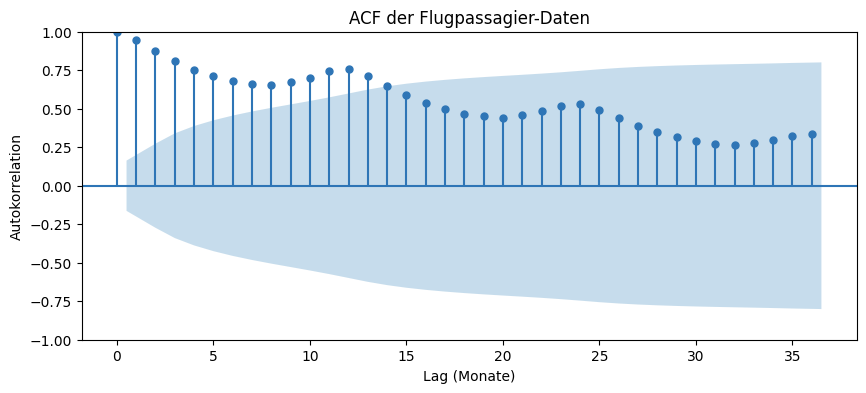

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf

df = pd.read_csv('airline-passengers.csv', parse_dates=['Month'], index_col='Month')
ts = df['Passengers']

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(ts, lags=36, ax=ax, color='#2E75B6', vlines_kwargs={'color': '#2E75B6'})
ax.set(title='ACF der Flugpassagier-Daten', xlabel='Lag (Monate)', ylabel='Autokorrelation')

# Saisonale Spitzen markieren
for lag in [12, 24, 36]:
    ax.annotate(f'Lag {lag}', xy=(lag, ax.lines[0].get_ydata()[lag]),
                xytext=(lag, 0.85), fontsize=9, color='#E8710A', fontweight='bold',
                ha='center', arrowprops=dict(arrowstyle='->', color='#E8710A', lw=1.2))

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('block4_acf_airpassengers.png', dpi=200)
plt.show()

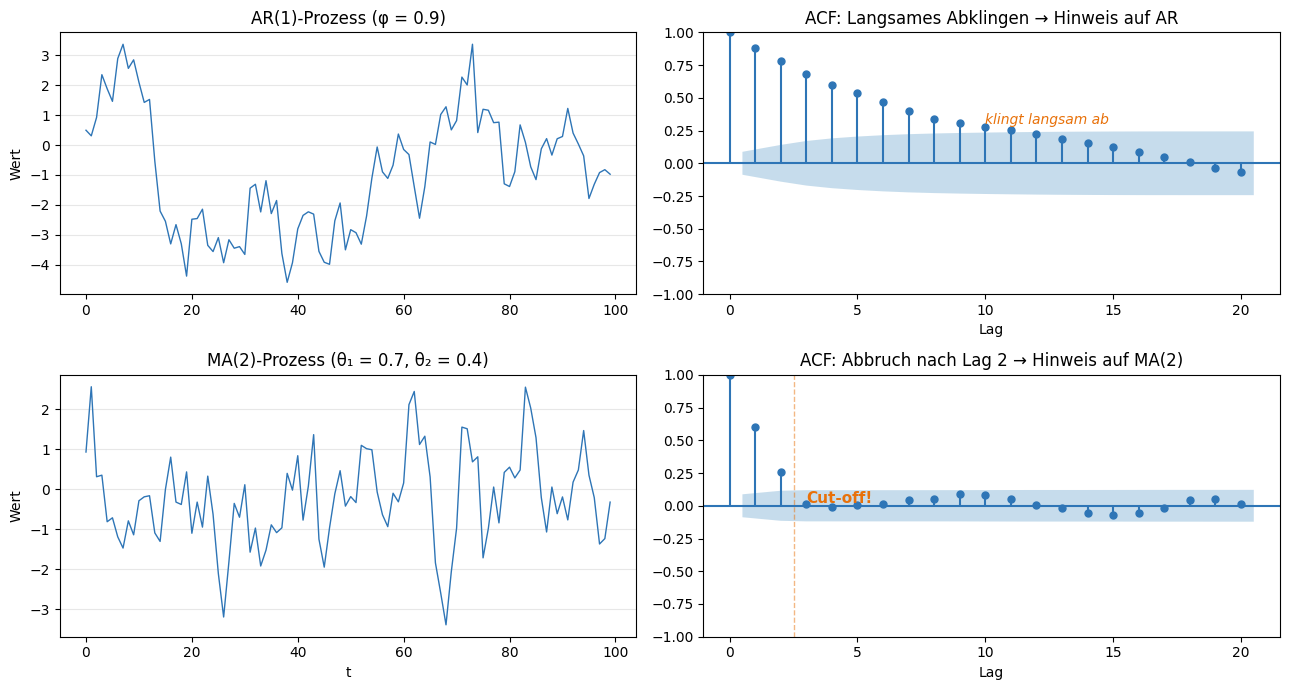

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(42)
n = 500

# AR(1): langsam abklingende ACF
ar1 = ArmaProcess([1, -0.9], [1]).generate_sample(n)

# MA(2): ACF bricht nach Lag 2 ab
ma2 = ArmaProcess([1], [1, 0.7, 0.4]).generate_sample(n)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Oben: AR(1)
axes[0, 0].plot(ar1[:100], color='#2E75B6', lw=1)
axes[0, 0].set(title='AR(1)-Prozess (φ = 0.9)', ylabel='Wert')
axes[0, 0].grid(axis='y', alpha=0.3)

plot_acf(ar1, lags=20, ax=axes[0, 1], color='#2E75B6', vlines_kwargs={'color': '#2E75B6'})
axes[0, 1].set(title='ACF: Langsames Abklingen → Hinweis auf AR', xlabel='Lag')
axes[0, 1].annotate('klingt langsam ab', xy=(10, 0.3), fontsize=10,
                     color='#E8710A', fontstyle='italic')

# Unten: MA(2)
axes[1, 0].plot(ma2[:100], color='#2E75B6', lw=1)
axes[1, 0].set(title='MA(2)-Prozess (θ₁ = 0.7, θ₂ = 0.4)', ylabel='Wert', xlabel='t')
axes[1, 0].grid(axis='y', alpha=0.3)

plot_acf(ma2, lags=20, ax=axes[1, 1], color='#2E75B6', vlines_kwargs={'color': '#2E75B6'})
axes[1, 1].set(title='ACF: Abbruch nach Lag 2 → Hinweis auf MA(2)', xlabel='Lag')
axes[1, 1].annotate('Cut-off!', xy=(3, 0.02), fontsize=11,
                     color='#E8710A', fontweight='bold')
axes[1, 1].axvline(2.5, color='#E8710A', ls='--', lw=1, alpha=0.5)

plt.tight_layout()
plt.savefig('block4_acf_muster_vergleich.png', dpi=200)
plt.show()

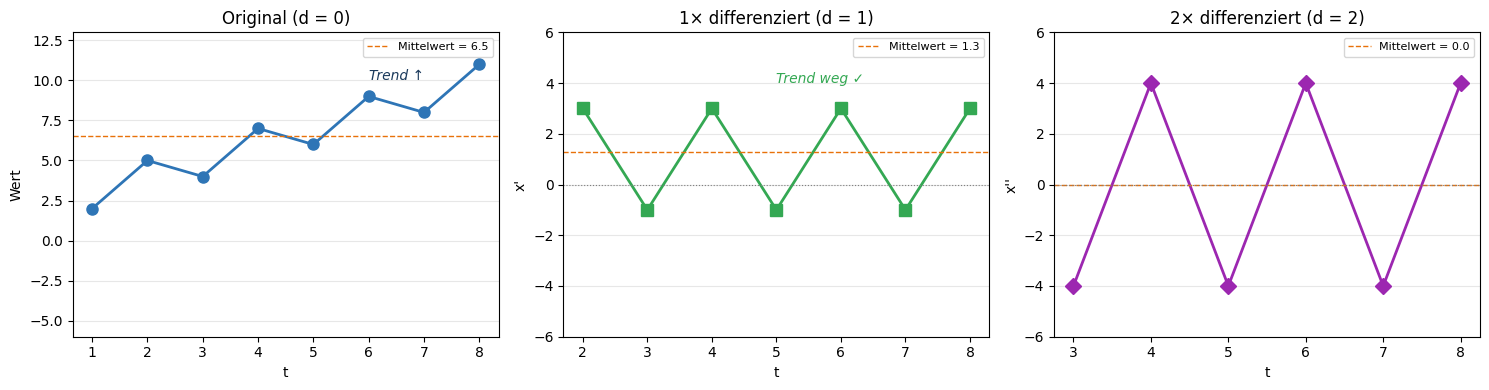

In [16]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([2, 5, 4, 7, 6, 9, 8, 11])
d1 = np.diff(x)        # [3, -1, 3, -1, 3, -1, 3]
d2 = np.diff(d1)        # [-4, 4, -4, 4, -4, 4]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
axes[0].plot(range(1, 9), x, 'o-', color='#2E75B6', lw=2, ms=8)
axes[0].axhline(x.mean(), color='#E8710A', ls='--', lw=1, label=f'Mittelwert = {x.mean():.1f}')
axes[0].set(title='Original (d = 0)', xlabel='t', ylabel='Wert',
            xticks=range(1, 9), ylim=(-6, 13))
axes[0].legend(fontsize=8)
axes[0].annotate('Trend ↑', xy=(6, 10), color='#1B3A5C', fontsize=10, fontstyle='italic')

# d = 1
axes[1].plot(range(2, 9), d1, 's-', color='#34A853', lw=2, ms=8)
axes[1].axhline(d1.mean(), color='#E8710A', ls='--', lw=1, label=f'Mittelwert = {d1.mean():.1f}')
axes[1].axhline(0, color='gray', ls=':', lw=0.8)
axes[1].set(title='1× differenziert (d = 1)', xlabel='t', ylabel="x'",
            xticks=range(2, 9), ylim=(-6, 6))
axes[1].legend(fontsize=8)
axes[1].annotate('Trend weg ✓', xy=(5, 4), color='#34A853', fontsize=10, fontstyle='italic')

# d = 2
axes[2].plot(range(3, 9), d2, 'D-', color='#9C27B0', lw=2, ms=8)
axes[2].axhline(d2.mean(), color='#E8710A', ls='--', lw=1, label=f'Mittelwert = {d2.mean():.1f}')
axes[2].axhline(0, color='gray', ls=':', lw=0.8)
axes[2].set(title='2× differenziert (d = 2)', xlabel='t', ylabel="x''",
            xticks=range(3, 9), ylim=(-6, 6))
axes[2].legend(fontsize=8)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('block5_differenzierung_mini.png', dpi=200)
plt.show()

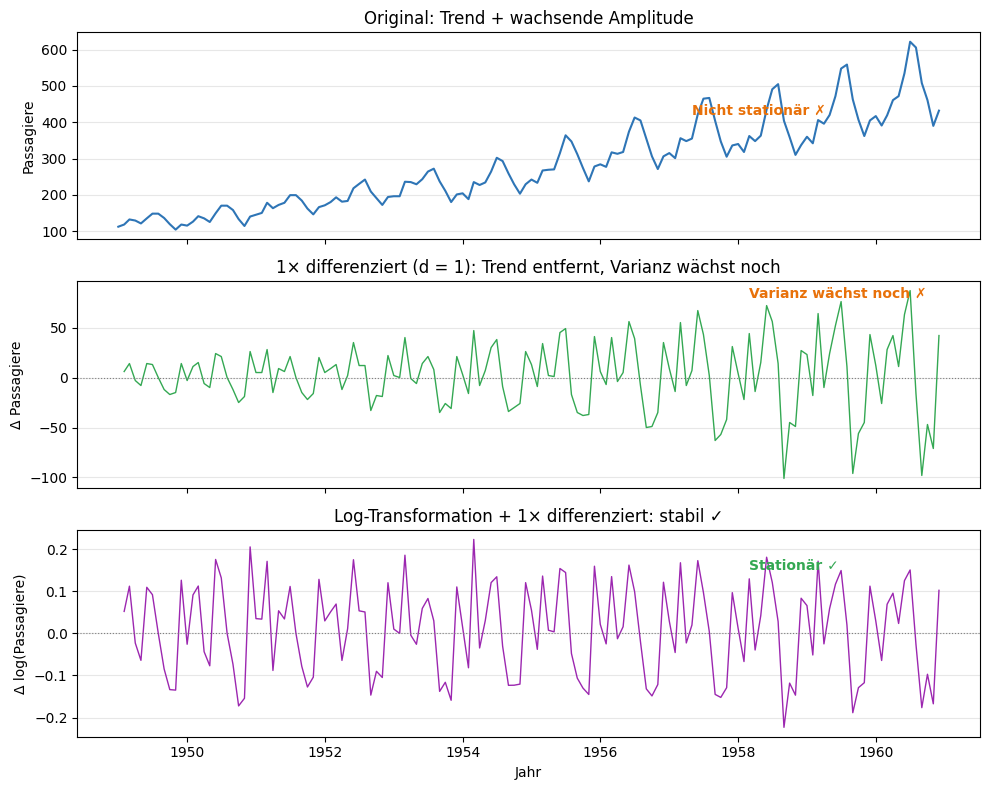

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('airline-passengers.csv', parse_dates=['Month'], index_col='Month')
ts = df['Passengers']

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Original
axes[0].plot(ts, color='#2E75B6', lw=1.5)
axes[0].set(title='Original: Trend + wachsende Amplitude', ylabel='Passagiere')
axes[0].annotate('Nicht stationär ✗', xy=(ts.index[100], 420),
                 fontsize=10, color='#E8710A', fontweight='bold')

# d = 1
d1 = ts.diff().dropna()
axes[1].plot(d1, color='#34A853', lw=1)
axes[1].axhline(0, color='gray', ls=':', lw=0.8)
axes[1].set(title='1× differenziert (d = 1): Trend entfernt, Varianz wächst noch',
            ylabel='Δ Passagiere')
axes[1].annotate('Varianz wächst noch ✗', xy=(ts.index[110], 80),
                 fontsize=10, color='#E8710A', fontweight='bold')

# Log + d = 1
import numpy as np
log_d1 = np.log(ts).diff().dropna()
axes[2].plot(log_d1, color='#9C27B0', lw=1)
axes[2].axhline(0, color='gray', ls=':', lw=0.8)
axes[2].set(title='Log-Transformation + 1× differenziert: stabil ✓',
            ylabel='Δ log(Passagiere)', xlabel='Jahr')
axes[2].annotate('Stationär ✓', xy=(ts.index[110], 0.15),
                 fontsize=10, color='#34A853', fontweight='bold')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('block5_differenzierung_airpassengers.png', dpi=200)
plt.show()

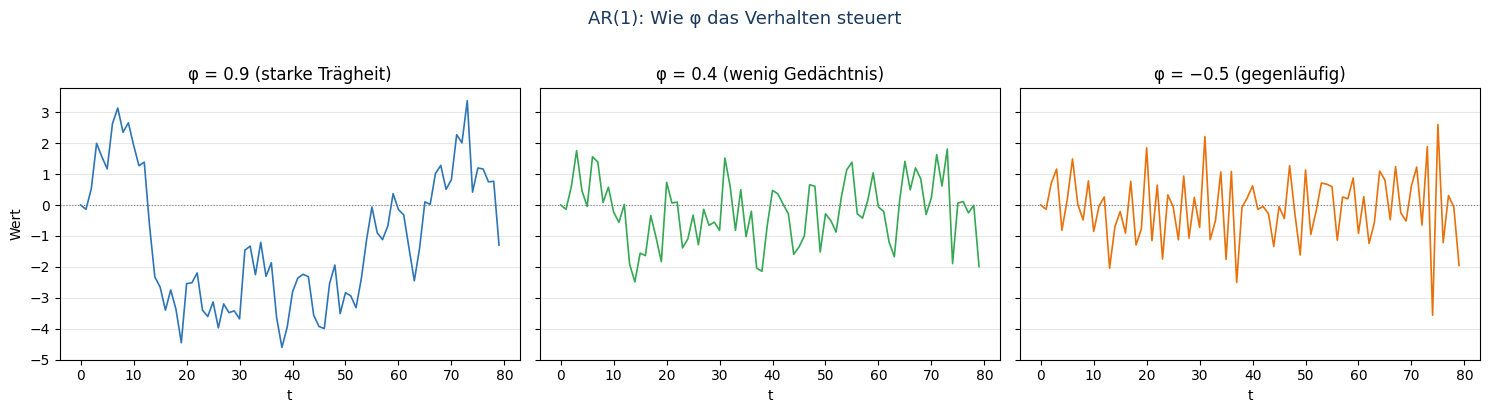

In [18]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n = 80
eps = np.random.normal(0, 1, n)

phis = [0.9, 0.4, -0.5]
labels = ['φ = 0.9 (starke Trägheit)', 'φ = 0.4 (wenig Gedächtnis)', 'φ = −0.5 (gegenläufig)']
colors = ['#2E75B6', '#34A853', '#E8710A']

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, phi, label, col in zip(axes, phis, labels, colors):
    x = np.zeros(n)
    x[0] = 0
    for t in range(1, n):
        x[t] = phi * x[t-1] + eps[t]
    ax.plot(x, color=col, lw=1.2)
    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.set(title=label, xlabel='t')
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Wert')
plt.suptitle('AR(1): Wie φ das Verhalten steuert', fontsize=13, color='#1B3A5C', y=1.02)
plt.tight_layout()
plt.savefig('block6_ar1_phi_vergleich.png', dpi=200)
plt.show()

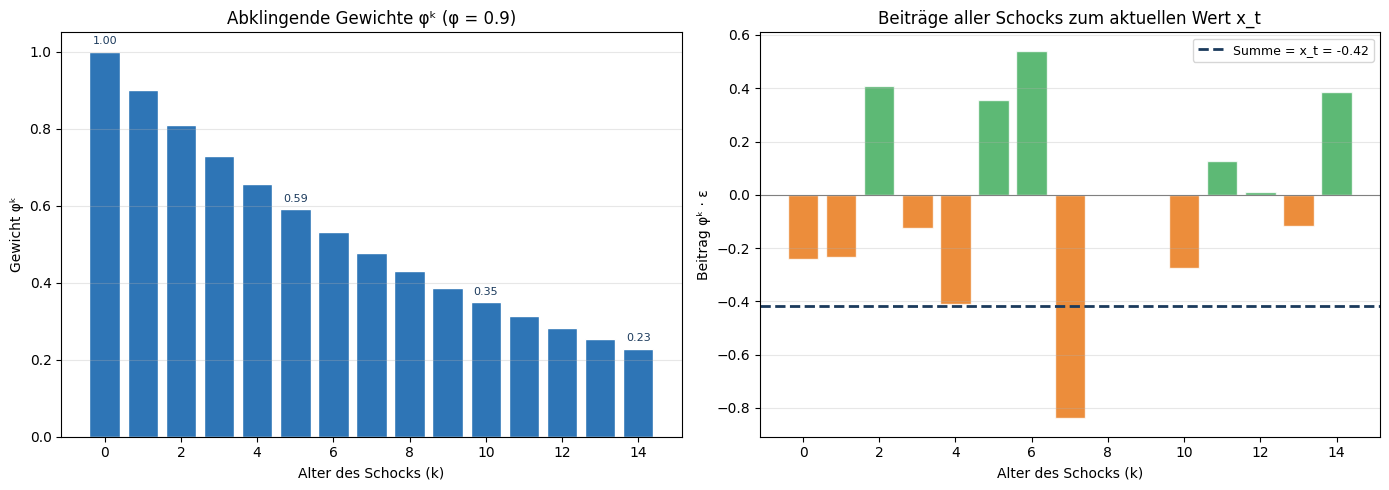

In [20]:
import matplotlib.pyplot as plt
import numpy as np

phi = 0.9
n_shocks = 15

np.random.seed(7)
eps = np.random.normal(0, 1, n_shocks)

# Gewichte: phi^k
weights = np.array([phi**k for k in range(n_shocks)])
contributions = weights * eps[::-1]  # ältester Schock zuerst

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Links: Gewichte abklingen
lags = range(n_shocks)
ax1.bar(lags, weights, color='#2E75B6', edgecolor='white')
ax1.set(title=f'Abklingende Gewichte φᵏ (φ = {phi})',
        xlabel='Alter des Schocks (k)', ylabel='Gewicht φᵏ')
ax1.grid(axis='y', alpha=0.3)
for i in [0, 5, 10, 14]:
    ax1.text(i, weights[i] + 0.02, f'{weights[i]:.2f}', ha='center', fontsize=8, color='#1B3A5C')

# Rechts: Gestapelte Beiträge zum aktuellen Wert
colors = ['#34A853' if c >= 0 else '#E8710A' for c in contributions]
bars = ax2.bar(range(n_shocks), contributions, color=colors, edgecolor='white', alpha=0.8)
ax2.axhline(0, color='gray', lw=0.8)
ax2.axhline(sum(contributions), color='#1B3A5C', ls='--', lw=2,
            label=f'Summe = x_t = {sum(contributions):.2f}')
ax2.set(title=f'Beiträge aller Schocks zum aktuellen Wert x_t',
        xlabel='Alter des Schocks (k)', ylabel='Beitrag φᵏ · ε')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('block6_exkurs_aufstapelung.png', dpi=200)
plt.show()

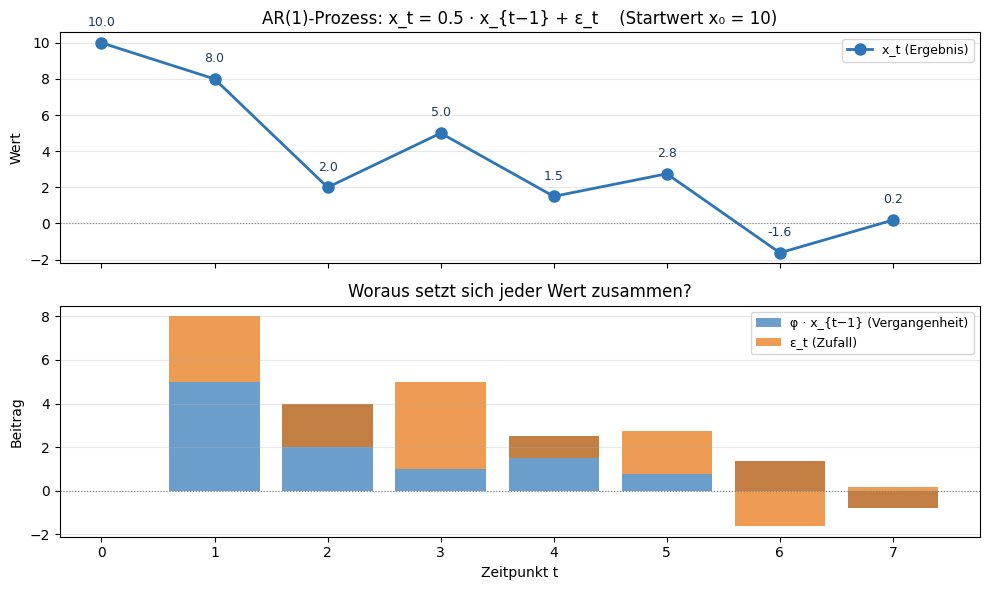

In [19]:
import matplotlib.pyplot as plt
import numpy as np

phi = 0.5
x0 = 10
errors = [0, 3, -2, 4, -1, 2, -3, 1]  # ε₀ = 0 als Platzhalter

x = [x0]
contributions_past = [0]
contributions_error = [0]

for t in range(1, len(errors)):
    past = phi * x[t-1]
    x.append(past + errors[t])
    contributions_past.append(past)
    contributions_error.append(errors[t])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Oben: Zeitreihe mit Zerlegung
t = range(len(x))
ax1.plot(t, x, 'o-', color='#2E75B6', lw=2, ms=8, label='x_t (Ergebnis)', zorder=3)
for i in range(len(x)):
    ax1.annotate(f'{x[i]:.1f}', (i, x[i]), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=9, color='#1B3A5C')
ax1.axhline(0, color='gray', ls=':', lw=0.8)
ax1.set(title=f'AR(1)-Prozess: x_t = {phi} · x_{{t−1}} + ε_t    (Startwert x₀ = {x0})',
        ylabel='Wert')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Unten: Gestapelte Beiträge
bars1 = ax2.bar(t[1:], contributions_past[1:], color='#2E75B6', alpha=0.7, label=f'φ · x_{{t−1}} (Vergangenheit)')
bars2 = ax2.bar(t[1:], contributions_error[1:], bottom=contributions_past[1:],
                color='#E8710A', alpha=0.7, label='ε_t (Zufall)')
ax2.axhline(0, color='gray', ls=':', lw=0.8)
ax2.set(title='Woraus setzt sich jeder Wert zusammen?',
        xlabel='Zeitpunkt t', ylabel='Beitrag')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('block6_ar1_beispielrechnung.png', dpi=200)
plt.show()

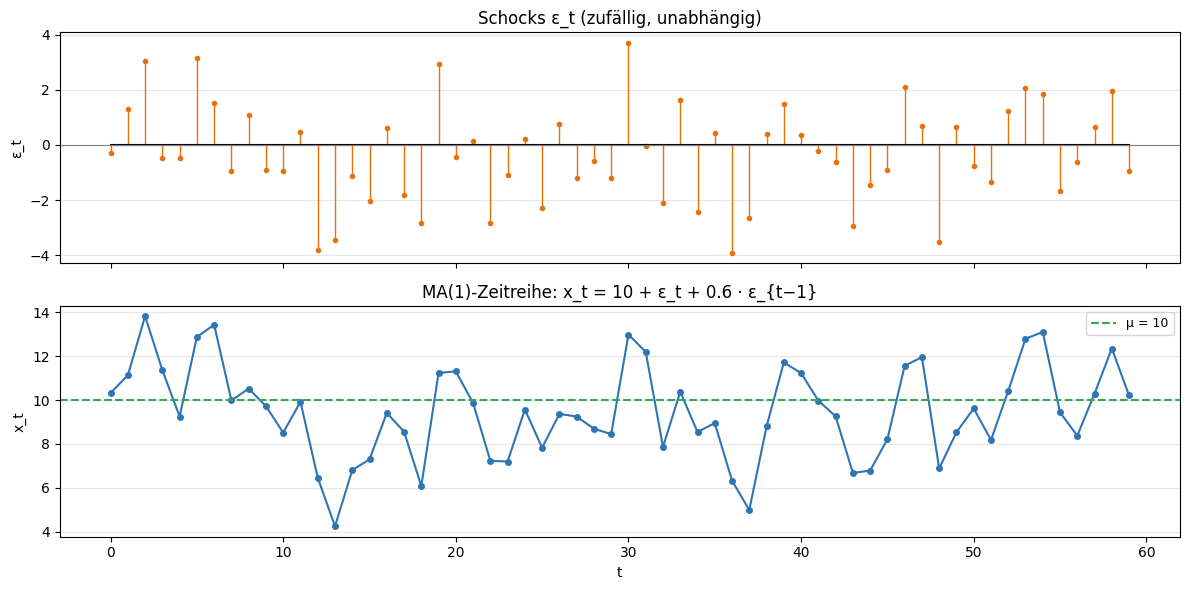

In [21]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n = 60
mu = 10
theta = 0.6
eps = np.random.normal(0, 2, n + 1)  # ein extra für ε₀

x = np.zeros(n)
for t in range(n):
    x[t] = mu + eps[t + 1] + theta * eps[t]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Oben: Schocks (ε)
markerline, stemlines, baseline = ax1.stem(range(n), eps[1:], linefmt='-', markerfmt='o', basefmt='k-')
stemlines.set_color('#E8710A')
stemlines.set_linewidth(1)
markerline.set_color('#E8710A')
markerline.set_markersize(3)
ax1.axhline(0, color='gray', lw=0.8)
ax1.set(title='Schocks ε_t (zufällig, unabhängig)', ylabel='ε_t')
ax1.grid(axis='y', alpha=0.3)

# Unten: Resultierende MA(1)-Zeitreihe
ax2.plot(x, 'o-', color='#2E75B6', lw=1.5, ms=4)
ax2.axhline(mu, color='#34A853', ls='--', lw=1.5, label=f'μ = {mu}')
ax2.set(title=f'MA(1)-Zeitreihe: x_t = {mu} + ε_t + {theta} · ε_{{t−1}}',
        xlabel='t', ylabel='x_t')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('block7_ma1_glocke.png', dpi=200)
plt.show()

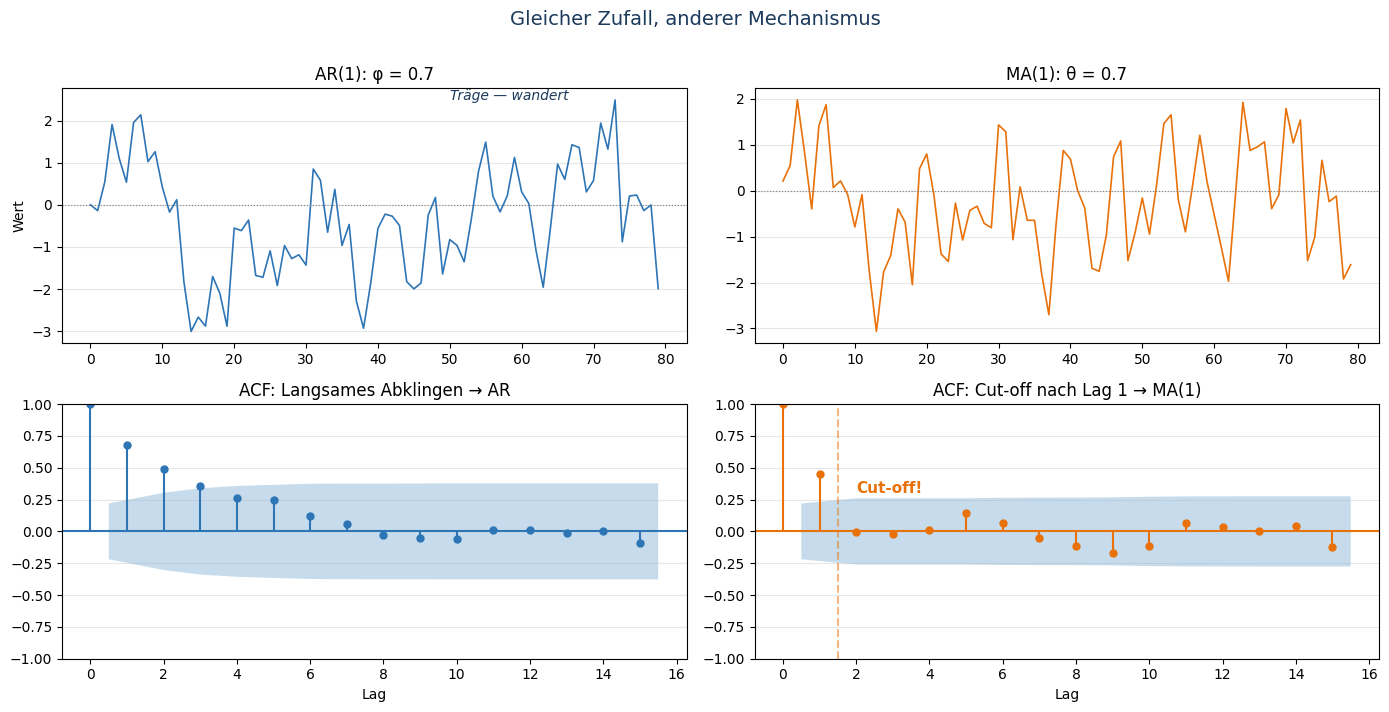

In [22]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n = 80
eps = np.random.normal(0, 1, n + 1)

# AR(1) mit phi=0.7
ar = np.zeros(n)
for t in range(1, n):
    ar[t] = 0.7 * ar[t-1] + eps[t]

# MA(1) mit theta=0.7
ma = np.zeros(n)
for t in range(n):
    ma[t] = eps[t + 1] + 0.7 * eps[t]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# Zeitreihen
axes[0, 0].plot(ar, color='#2E75B6', lw=1.2)
axes[0, 0].set(title='AR(1): φ = 0.7', ylabel='Wert')
axes[0, 0].axhline(0, color='gray', ls=':', lw=0.8)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].annotate('Träge — wandert', xy=(50, 2.5), fontsize=10,
                     color='#1B3A5C', fontstyle='italic')

axes[0, 1].plot(ma, color='#E8710A', lw=1.2)
axes[0, 1].set(title='MA(1): θ = 0.7')
axes[0, 1].axhline(0, color='gray', ls=':', lw=0.8)
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].annotate('Nervös — springt', xy=(50, 2.5), fontsize=10,
                     color='#1B3A5C', fontstyle='italic')

# ACFs
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(ar, lags=15, ax=axes[1, 0], color='#2E75B6', vlines_kwargs={'color': '#2E75B6'})
axes[1, 0].set(title='ACF: Langsames Abklingen → AR', xlabel='Lag')
axes[1, 0].grid(axis='y', alpha=0.3)

plot_acf(ma, lags=15, ax=axes[1, 1], color='#E8710A', vlines_kwargs={'color': '#E8710A'})
axes[1, 1].set(title='ACF: Cut-off nach Lag 1 → MA(1)', xlabel='Lag')
axes[1, 1].axvline(1.5, color='#E8710A', ls='--', lw=1.5, alpha=0.5)
axes[1, 1].annotate('Cut-off!', xy=(2, 0.3), fontsize=11,
                     color='#E8710A', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Gleicher Zufall, anderer Mechanismus', fontsize=14, color='#1B3A5C', y=1.01)
plt.tight_layout()
plt.savefig('block7_ar_vs_ma.png', dpi=200)
plt.show()

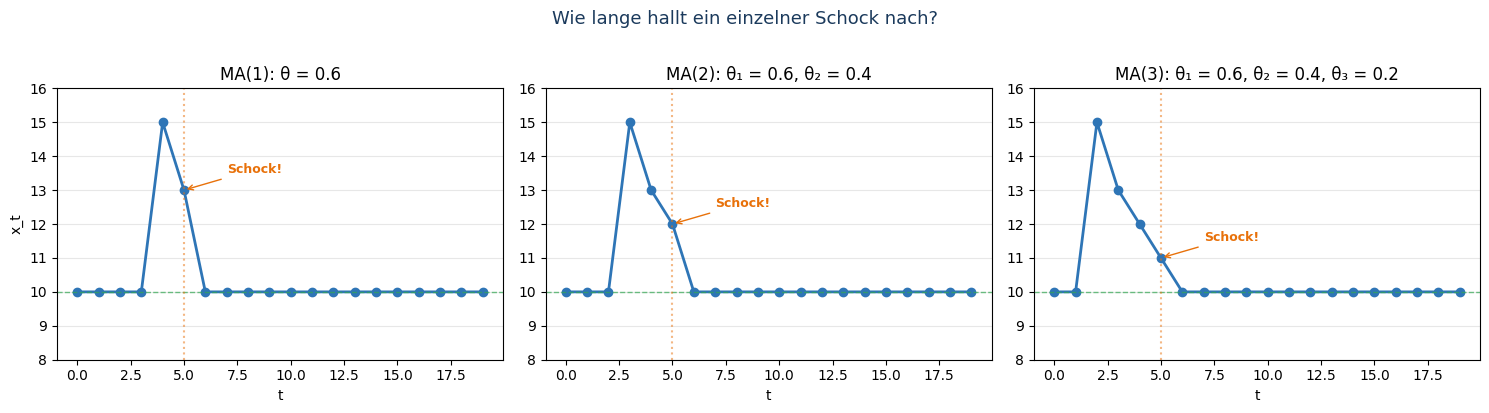

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Ein einzelner Schock bei t=5, sonst Stille
n = 20
mu = 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, q, thetas, label in [
    (axes[0], 1, [0.6], 'MA(1): θ = 0.6'),
    (axes[1], 2, [0.6, 0.4], 'MA(2): θ₁ = 0.6, θ₂ = 0.4'),
    (axes[2], 3, [0.6, 0.4, 0.2], 'MA(3): θ₁ = 0.6, θ₂ = 0.4, θ₃ = 0.2'),
]:
    eps = np.zeros(n + q)
    eps[5] = 5  # ein großer Schock bei t=5

    x = np.zeros(n)
    for t in range(n):
        x[t] = mu + eps[t + q]
        for j in range(q):
            x[t] += thetas[j] * eps[t + q - 1 - j]

    ax.plot(range(n), x, 'o-', color='#2E75B6', lw=2, ms=6)
    ax.axhline(mu, color='#34A853', ls='--', lw=1, alpha=0.7)

    # Schock-Zeitpunkt markieren
    ax.axvline(5, color='#E8710A', ls=':', lw=1.5, alpha=0.5)
    ax.annotate('Schock!', xy=(5, x[5]), xytext=(7, x[5] + 0.5),
                fontsize=9, color='#E8710A', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#E8710A'))

    ax.set(title=label, xlabel='t', ylim=(8, 16))
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('x_t')
plt.suptitle('Wie lange hallt ein einzelner Schock nach?', fontsize=13, color='#1B3A5C', y=1.02)
plt.tight_layout()
plt.savefig('block7_ma_gedaechtnis.png', dpi=200)
plt.show()

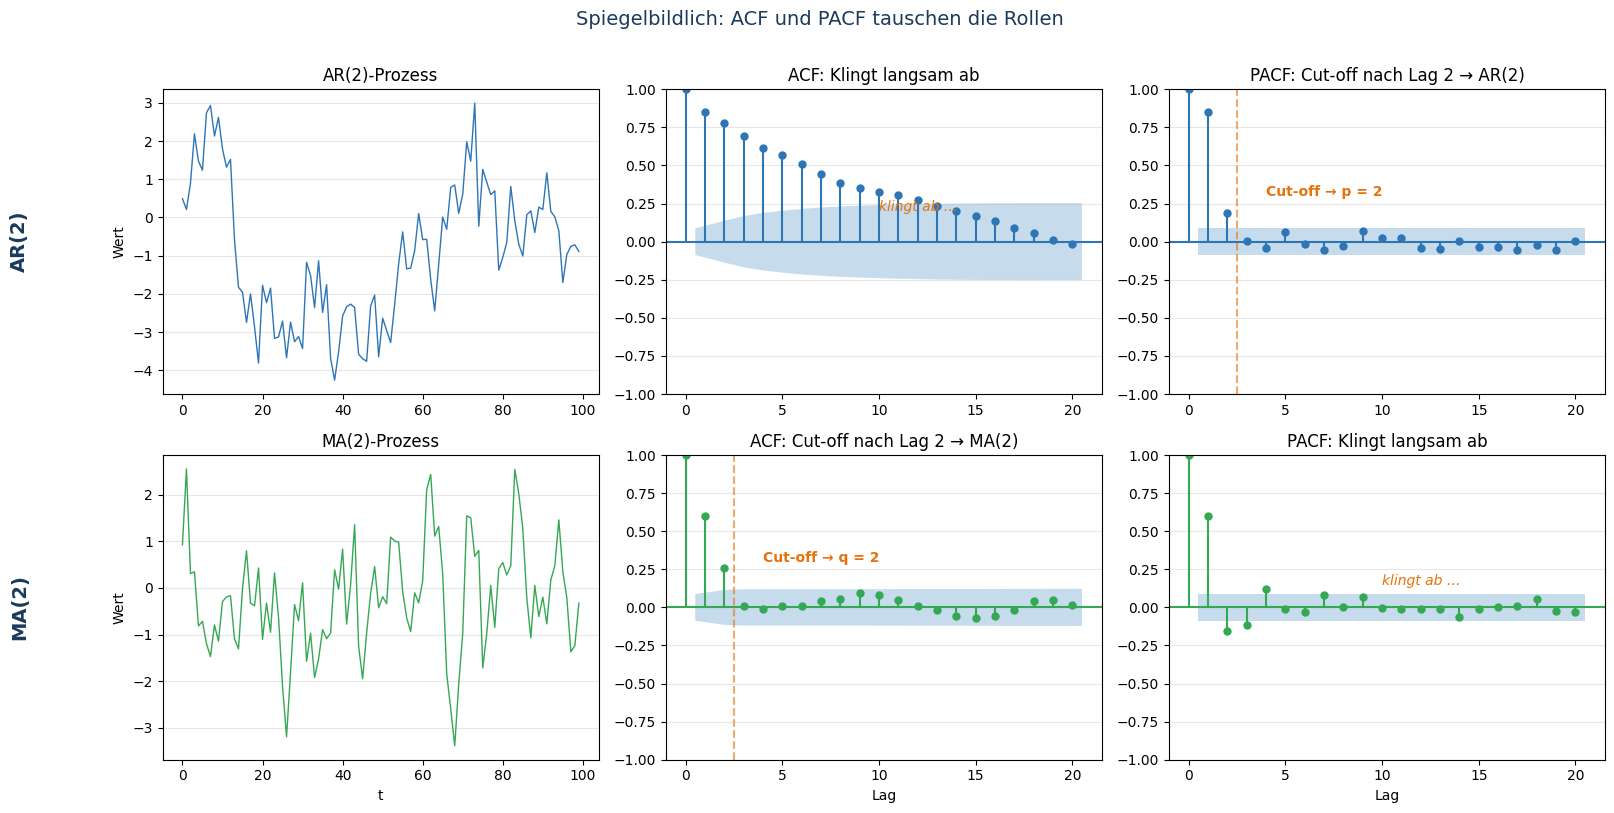

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)
n = 500

# AR(2)-Prozess
ar2 = ArmaProcess([1, -0.7, -0.2], [1]).generate_sample(n)

# MA(2)-Prozess
ma2 = ArmaProcess([1], [1, 0.7, 0.4]).generate_sample(n)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# ── Oben: AR(2) ──
axes[0, 0].plot(ar2[:100], color='#2E75B6', lw=1)
axes[0, 0].set(title='AR(2)-Prozess', ylabel='Wert')
axes[0, 0].grid(axis='y', alpha=0.3)

plot_acf(ar2, lags=20, ax=axes[0, 1], color='#2E75B6', vlines_kwargs={'color': '#2E75B6'})
axes[0, 1].set(title='ACF: Klingt langsam ab')
axes[0, 1].annotate('klingt ab …', xy=(10, 0.2), fontsize=10,
                     color='#E8710A', fontstyle='italic')

plot_pacf(ar2, lags=20, ax=axes[0, 2], color='#2E75B6', vlines_kwargs={'color': '#2E75B6'})
axes[0, 2].set(title='PACF: Cut-off nach Lag 2 → AR(2)')
axes[0, 2].axvline(2.5, color='#E8710A', ls='--', lw=1.5, alpha=0.6)
axes[0, 2].annotate('Cut-off → p = 2', xy=(4, 0.3), fontsize=10,
                     color='#E8710A', fontweight='bold')

# ── Unten: MA(2) ──
axes[1, 0].plot(ma2[:100], color='#34A853', lw=1)
axes[1, 0].set(title='MA(2)-Prozess', ylabel='Wert', xlabel='t')
axes[1, 0].grid(axis='y', alpha=0.3)

plot_acf(ma2, lags=20, ax=axes[1, 1], color='#34A853', vlines_kwargs={'color': '#34A853'})
axes[1, 1].set(title='ACF: Cut-off nach Lag 2 → MA(2)', xlabel='Lag')
axes[1, 1].axvline(2.5, color='#E8710A', ls='--', lw=1.5, alpha=0.6)
axes[1, 1].annotate('Cut-off → q = 2', xy=(4, 0.3), fontsize=10,
                     color='#E8710A', fontweight='bold')

plot_pacf(ma2, lags=20, ax=axes[1, 2], color='#34A853', vlines_kwargs={'color': '#34A853'})
axes[1, 2].set(title='PACF: Klingt langsam ab', xlabel='Lag')
axes[1, 2].annotate('klingt ab …', xy=(10, 0.15), fontsize=10,
                     color='#E8710A', fontstyle='italic')

# Zeilen-Labels
axes[0, 0].text(-0.35, 0.5, 'AR(2)', transform=axes[0, 0].transAxes,
                fontsize=14, fontweight='bold', color='#1B3A5C', va='center', rotation=90)
axes[1, 0].text(-0.35, 0.5, 'MA(2)', transform=axes[1, 0].transAxes,
                fontsize=14, fontweight='bold', color='#1B3A5C', va='center', rotation=90)

for ax in axes.flat:
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Spiegelbildlich: ACF und PACF tauschen die Rollen', fontsize=14, color='#1B3A5C', y=1.01)
plt.tight_layout()
plt.savefig('block8_acf_vs_pacf.png', dpi=200)
plt.show()

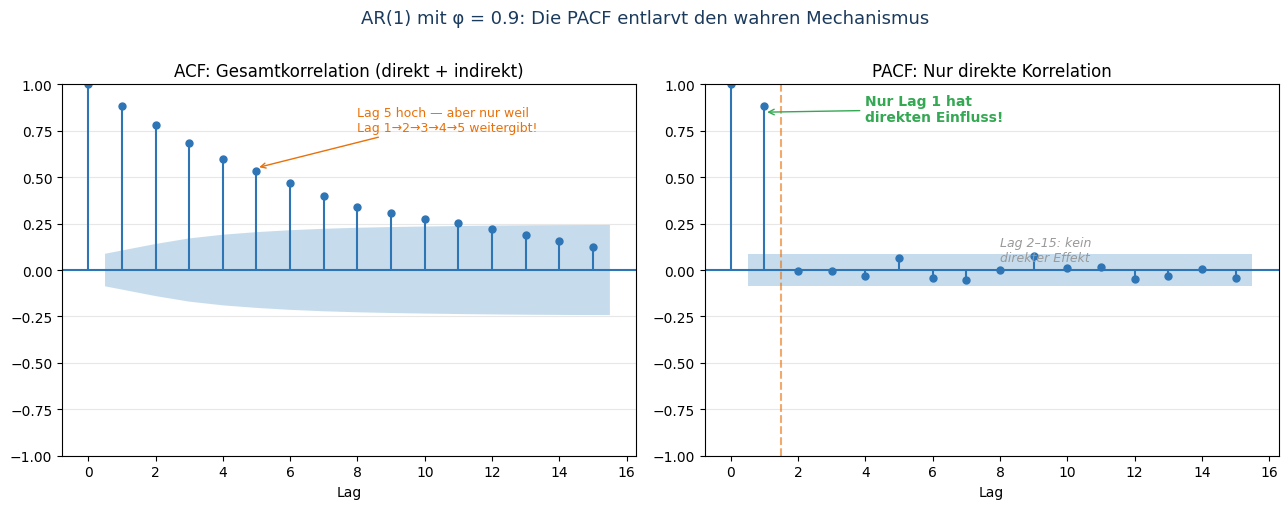

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(42)
ar1 = ArmaProcess([1, -0.9], [1]).generate_sample(500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

plot_acf(ar1, lags=15, ax=ax1, color='#2E75B6', vlines_kwargs={'color': '#2E75B6'})
ax1.set(title='ACF: Gesamtkorrelation (direkt + indirekt)', xlabel='Lag')
ax1.annotate('Lag 5 hoch — aber nur weil\nLag 1→2→3→4→5 weitergibt!',
             xy=(5, 0.55), xytext=(8, 0.75), fontsize=9, color='#E8710A',
             arrowprops=dict(arrowstyle='->', color='#E8710A'))
ax1.grid(axis='y', alpha=0.3)

plot_pacf(ar1, lags=15, ax=ax2, color='#2E75B6', vlines_kwargs={'color': '#2E75B6'})
ax2.set(title='PACF: Nur direkte Korrelation', xlabel='Lag')
ax2.axvline(1.5, color='#E8710A', ls='--', lw=1.5, alpha=0.6)
ax2.annotate('Nur Lag 1 hat\ndirekten Einfluss!',
             xy=(1, 0.85), xytext=(4, 0.8), fontsize=10, color='#34A853',
             fontweight='bold', arrowprops=dict(arrowstyle='->', color='#34A853'))
ax2.annotate('Lag 2–15: kein\ndirekter Effekt',
             xy=(8, 0.05), fontsize=9, color='#999999', fontstyle='italic')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('AR(1) mit φ = 0.9: Die PACF entlarvt den wahren Mechanismus',
             fontsize=13, color='#1B3A5C', y=1.01)
plt.tight_layout()
plt.savefig('block8_pacf_erklaert.png', dpi=200)
plt.show()

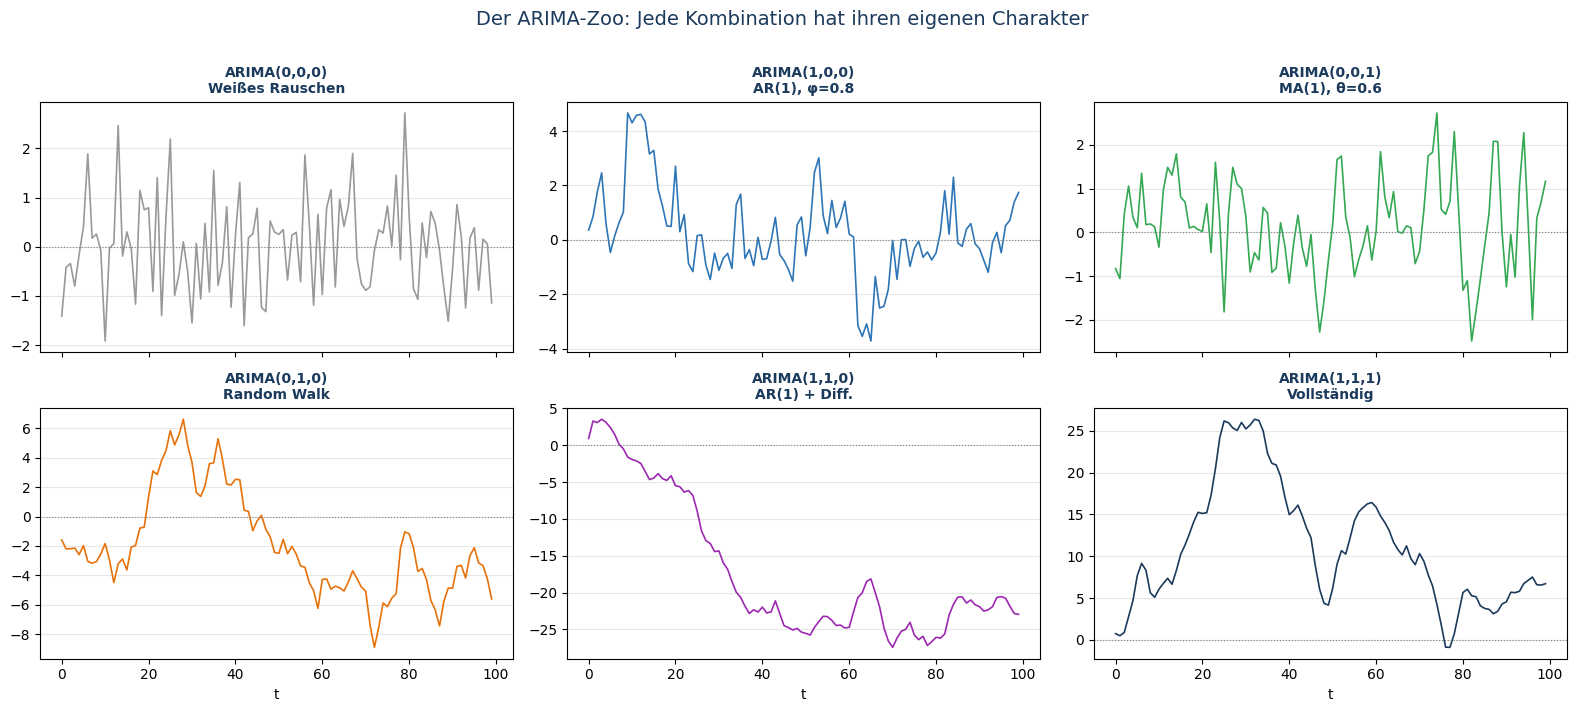

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(42)
n = 100
eps = np.random.normal(0, 1, n)

cases = {
    'ARIMA(0,0,0)\nWeißes Rauschen':    np.random.normal(0, 1, n),
    'ARIMA(1,0,0)\nAR(1), φ=0.8':       ArmaProcess([1, -0.8], [1]).generate_sample(n),
    'ARIMA(0,0,1)\nMA(1), θ=0.6':       ArmaProcess([1], [1, 0.6]).generate_sample(n),
    'ARIMA(0,1,0)\nRandom Walk':         np.cumsum(np.random.normal(0, 1, n)),
    'ARIMA(1,1,0)\nAR(1) + Diff.':       np.cumsum(ArmaProcess([1, -0.5], [1]).generate_sample(n)),
    'ARIMA(1,1,1)\nVollständig':         np.cumsum(ArmaProcess([1, -0.5], [1, 0.4]).generate_sample(n)),
}

colors = ['#999999', '#2E75B6', '#34A853', '#E8710A', '#9C27B0', '#1B3A5C']

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)

for ax, (title, data), col in zip(axes.flat, cases.items(), colors):
    ax.plot(data, color=col, lw=1.2)
    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.set_title(title, fontsize=10, fontweight='bold', color='#1B3A5C')
    ax.grid(axis='y', alpha=0.3)

axes[1, 0].set_xlabel('t')
axes[1, 1].set_xlabel('t')
axes[1, 2].set_xlabel('t')

plt.suptitle('Der ARIMA-Zoo: Jede Kombination hat ihren eigenen Charakter',
             fontsize=14, color='#1B3A5C', y=1.01)
plt.tight_layout()
plt.savefig('block9_arima_zoo.png', dpi=200)
plt.show()

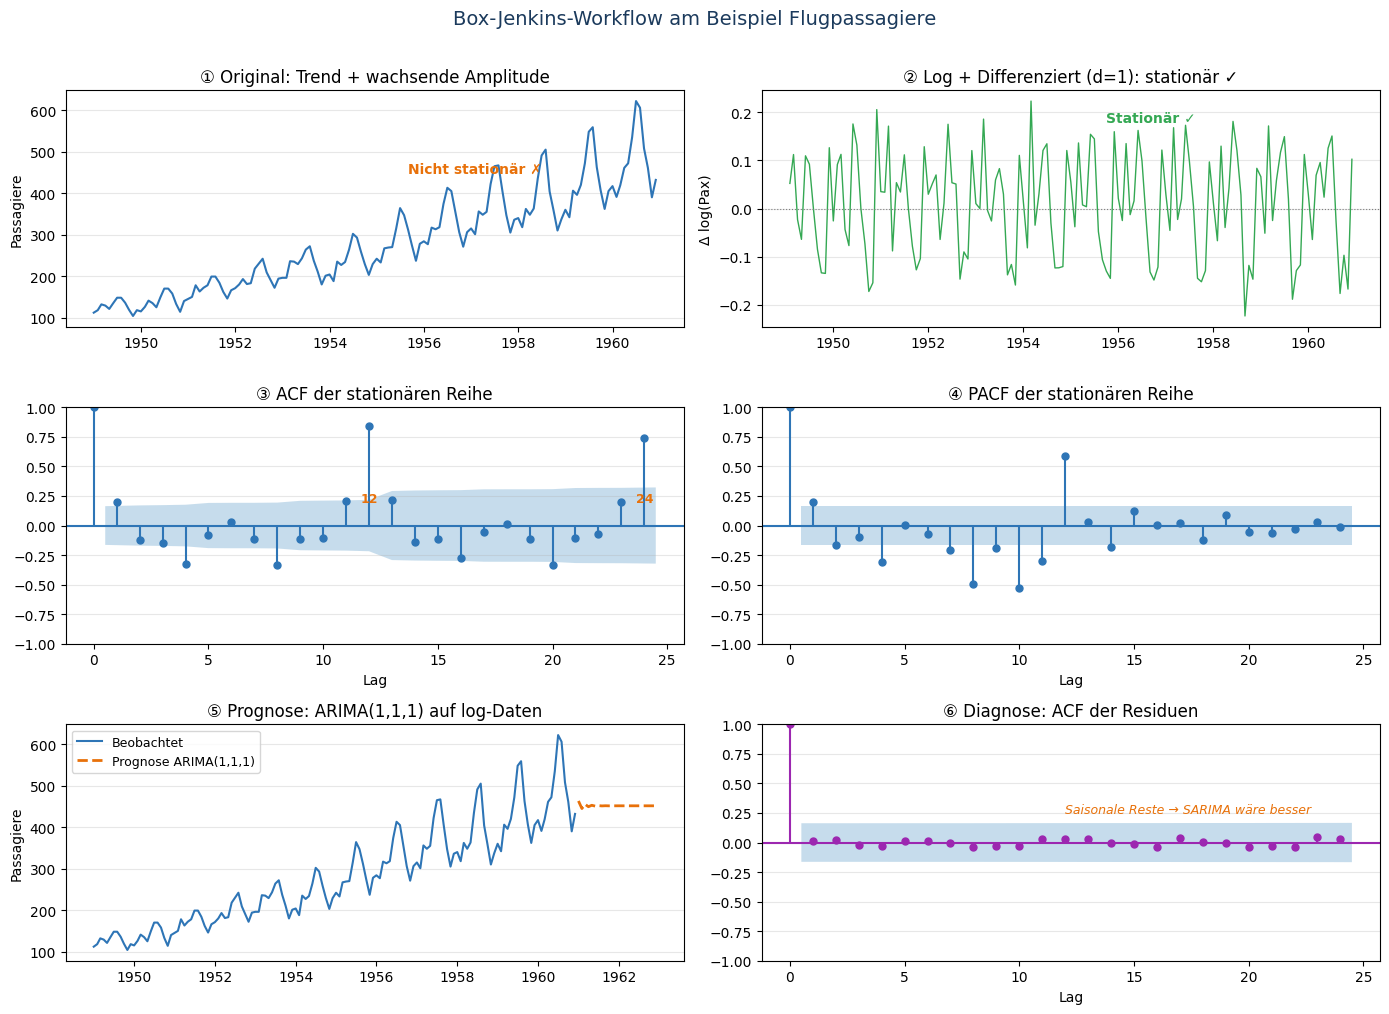

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df = pd.read_csv('airline-passengers.csv', parse_dates=['Month'], index_col='Month')
ts = df['Passengers']
ts.index.freq = 'MS'

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Schritt 1: Original → nicht stationär
axes[0, 0].plot(ts, color='#2E75B6', lw=1.5)
axes[0, 0].set(title='① Original: Trend + wachsende Amplitude', ylabel='Passagiere')
axes[0, 0].annotate('Nicht stationär ✗', xy=(ts.index[80], 450),
                     fontsize=10, color='#E8710A', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Schritt 1b: Log + Diff → stationär
log_diff = np.log(ts).diff().dropna()
axes[0, 1].plot(log_diff, color='#34A853', lw=1)
axes[0, 1].axhline(0, color='gray', ls=':', lw=0.8)
axes[0, 1].set(title='② Log + Differenziert (d=1): stationär ✓', ylabel='Δ log(Pax)')
axes[0, 1].annotate('Stationär ✓', xy=(log_diff.index[80], 0.18),
                     fontsize=10, color='#34A853', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Schritt 2: ACF + PACF
plot_acf(log_diff.dropna(), lags=24, ax=axes[1, 0], color='#2E75B6',
         vlines_kwargs={'color': '#2E75B6'})
axes[1, 0].set(title='③ ACF der stationären Reihe', xlabel='Lag')
for lag in [12, 24]:
    axes[1, 0].annotate(f'{lag}', xy=(lag, 0.2), fontsize=9,
                         color='#E8710A', fontweight='bold', ha='center')
axes[1, 0].grid(axis='y', alpha=0.3)

plot_pacf(log_diff.dropna(), lags=24, ax=axes[1, 1], color='#2E75B6',
          vlines_kwargs={'color': '#2E75B6'})
axes[1, 1].set(title='④ PACF der stationären Reihe', xlabel='Lag')
axes[1, 1].grid(axis='y', alpha=0.3)

# Schritt 3: Modell + Prognose
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(np.log(ts), order=(1, 1, 1))
fit = model.fit()
forecast = fit.forecast(steps=24)
forecast_exp = np.exp(forecast)

axes[2, 0].plot(ts, color='#2E75B6', lw=1.5, label='Beobachtet')
axes[2, 0].plot(forecast_exp.index, forecast_exp, color='#E8710A', lw=2,
                ls='--', label='Prognose ARIMA(1,1,1)')
axes[2, 0].legend(fontsize=9)
axes[2, 0].set(title='⑤ Prognose: ARIMA(1,1,1) auf log-Daten', ylabel='Passagiere')
axes[2, 0].grid(axis='y', alpha=0.3)

# Schritt 3b: Residuen prüfen
residuals = fit.resid.dropna()
plot_acf(residuals, lags=24, ax=axes[2, 1], color='#9C27B0',
         vlines_kwargs={'color': '#9C27B0'})
axes[2, 1].set(title='⑥ Diagnose: ACF der Residuen', xlabel='Lag')
axes[2, 1].annotate('Saisonale Reste → SARIMA wäre besser',
                     xy=(12, 0.25), fontsize=9, color='#E8710A', fontstyle='italic')
axes[2, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Box-Jenkins-Workflow am Beispiel Flugpassagiere',
             fontsize=14, color='#1B3A5C', y=1.01)
plt.tight_layout()
plt.savefig('block9_box_jenkins_workflow.png', dpi=200)
plt.show()

In [1]:
"""
Block 10 Visualisierungen für das ARIMA-Skript
=================================================
Erzeugt vier Abbildungen als PNG-Dateien, passend zu den Platzhaltern
im Zusatz-Skript „Prognose: Was ARIMA leisten kann – und was nicht".

Voraussetzungen:
    pip install matplotlib numpy statsmodels

Ausführen:
    python block10_visualisierungen.py

Ausgabe:
    viz1_trendlinie_vs_arima.png
    viz2_beispiel_prognose.png
    viz3_prognosehorizont.png
    viz4_strukturbruch.png
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────
# Globale Stil-Einstellungen
# ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# Farbpalette (konsistent über alle Plots)
C_DATA    = "#2E75B6"   # Datenpunkte
C_ARIMA   = "#E74C3C"   # ARIMA-Prognose
C_TREND   = "#95A5A6"   # Trendlinie
C_CONF1   = "#E74C3C"   # Konfidenzband eng
C_CONF2   = "#F5B7B1"   # Konfidenzband weit
C_ACCENT  = "#27AE60"   # Akzentfarbe

# Unsere Beispielzeitreihe
t_data = np.arange(1, 9)
x_data = np.array([2, 5, 4, 7, 6, 9, 8, 11])


# ══════════════════════════════════════════════
# Visualisierung 1:
# Trendlinien-Prognose vs. ARIMA-Prognose
# ══════════════════════════════════════════════
def viz1_trendlinie_vs_arima():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

    t_future = np.arange(9, 13)
    t_all = np.arange(1, 13)

    # --- Linke Seite: Lineare Trendlinie ---
    # Lineare Regression
    slope, intercept = np.polyfit(t_data, x_data, 1)
    trend_all = slope * t_all + intercept
    trend_future = slope * t_future + intercept

    ax1.plot(t_data, x_data, "o-", color=C_DATA, lw=2, ms=7, label="Beobachtete Daten", zorder=5)
    ax1.plot(t_all, trend_all, "--", color=C_TREND, lw=2, label=f"Trendlinie (Steigung={slope:.2f})")
    ax1.plot(t_future, trend_future, "s--", color=C_TREND, lw=2, ms=7, alpha=0.7)

    # Prognose-Bereich markieren
    ax1.axvspan(8.5, 12.5, alpha=0.06, color="grey")
    ax1.text(10.5, 2.5, "Prognose-\nbereich", ha="center", fontsize=9, color="grey", style="italic")

    ax1.set_title("Lineare Trendlinie")
    ax1.set_xlabel("Monat t")
    ax1.set_ylabel("Wert xₜ (Tsd. Stück)")
    ax1.set_xticks(range(1, 13))
    ax1.legend(loc="upper left", fontsize=9)
    ax1.set_xlim(0.5, 12.5)
    ax1.set_ylim(0, 16)

    # --- Rechte Seite: ARIMA-Prognose ---
    # Simuliertes ARIMA(1,1,0): alternierendes Muster fortschreiben
    # φ ≈ -0.8 auf differenzierter Reihe, μ ≈ 1.3
    phi = -0.8
    mu = 1.286  # Mittelwert der differenzierten Reihe
    last_diff = 3  # letzter Differenzwert (x8 - x7 = 11 - 8)

    arima_forecast = [x_data[-1]]
    diffs = [last_diff]
    for i in range(4):
        next_diff = mu + phi * diffs[-1]
        arima_forecast.append(arima_forecast[-1] + next_diff)
        diffs.append(next_diff)

    arima_forecast = np.array(arima_forecast[1:])  # nur die Prognose-Werte
    t_fc = np.arange(9, 13)

    # Konfidenzband (wächst mit der Wurzel der Schrittanzahl)
    sigma = 0.8  # geschätzte Residualstreuung
    steps = np.arange(1, 5)
    ci_width = 1.96 * sigma * np.sqrt(np.cumsum(np.ones(4) + phi**(2*steps)))

    ax2.plot(t_data, x_data, "o-", color=C_DATA, lw=2, ms=7, label="Beobachtete Daten", zorder=5)
    ax2.plot(t_fc, arima_forecast, "o--", color=C_ARIMA, lw=2, ms=7, label="ARIMA(1,1,0)", zorder=5)
    ax2.fill_between(t_fc, arima_forecast - ci_width, arima_forecast + ci_width,
                      alpha=0.15, color=C_ARIMA, label="95%-Konfidenzintervall")

    ax2.axvspan(8.5, 12.5, alpha=0.06, color="grey")
    ax2.text(10.5, 2.5, "Prognose-\nbereich", ha="center", fontsize=9, color="grey", style="italic")

    ax2.set_title("ARIMA(1,1,0)-Prognose")
    ax2.set_xlabel("Monat t")
    ax2.set_xticks(range(1, 13))
    ax2.legend(loc="upper left", fontsize=9)
    ax2.set_xlim(0.5, 12.5)

    fig.suptitle("Vergleich: Trendlinie vs. ARIMA-Prognose", fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig("viz1_trendlinie_vs_arima.png", bbox_inches="tight", facecolor="white")
    plt.close()
    print("✓ viz1_trendlinie_vs_arima.png erstellt")


# ══════════════════════════════════════════════
# Visualisierung 2:
# Beispiel-Prognose für t=9,10,11 mit unserer Zeitreihe
# ══════════════════════════════════════════════
def viz2_beispiel_prognose():
    fig, ax = plt.subplots(figsize=(10, 5))

    # ARIMA(1,1,0) Prognose
    phi = -0.8
    mu = 1.286
    last_diff = 3

    forecasts = [x_data[-1]]
    diffs = [last_diff]
    for i in range(3):
        nd = mu + phi * diffs[-1]
        forecasts.append(forecasts[-1] + nd)
        diffs.append(nd)
    forecasts = np.array(forecasts)

    t_fc = np.arange(8, 12)  # t=8 (letzter bekannter) bis t=11

    sigma = 0.8
    steps = np.arange(0, 4)
    ci_mult = np.array([0] + [1.96 * sigma * np.sqrt(s+1) for s in range(3)])

    # Beobachtete Daten
    ax.plot(t_data, x_data, "o-", color=C_DATA, lw=2.5, ms=8, label="Beobachtete Daten", zorder=5)

    # Prognose
    ax.plot(t_fc[1:], forecasts[1:], "D--", color=C_ARIMA, lw=2, ms=8, label="ARIMA-Prognose", zorder=5)
    ax.plot([t_fc[0], t_fc[1]], [forecasts[0], forecasts[1]], "--", color=C_ARIMA, lw=2, zorder=4)

    # Konfidenzband
    ax.fill_between(t_fc[1:], forecasts[1:] - ci_mult[1:], forecasts[1:] + ci_mult[1:],
                     alpha=0.15, color=C_ARIMA, label="95%-Konfidenzintervall")

    # Annotationen für die Rechenschritte
    for i in range(1, 4):
        t_i = t_fc[i]
        y_i = forecasts[i]
        diff_val = diffs[i]
        sign = "+" if diff_val >= 0 else ""
        ax.annotate(
            f"t={t_i}: x={forecasts[i-1]:.1f} {sign}{diff_val:.1f} = {y_i:.1f}",
            xy=(t_i, y_i), xytext=(t_i + 0.3, y_i + 1.5),
            fontsize=9, color=C_ARIMA,
            arrowprops=dict(arrowstyle="->", color=C_ARIMA, lw=1.2),
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=C_ARIMA, alpha=0.8)
        )

    # Trennlinie
    ax.axvline(8.5, color="grey", ls=":", lw=1, alpha=0.7)
    ax.text(8.6, 1.5, "← bekannt | Prognose →", fontsize=9, color="grey", style="italic")

    ax.set_xlabel("Monat t")
    ax.set_ylabel("Wert xₜ (Tsd. Stück)")
    ax.set_title("Ein-Schritt-Prognose mit ARIMA(1,1,0) auf unserer Beispielzeitreihe")
    ax.set_xticks(range(1, 12))
    ax.set_xlim(0.5, 11.8)
    ax.set_ylim(0, 15)
    ax.legend(loc="upper left")

    fig.tight_layout()
    fig.savefig("viz2_beispiel_prognose.png", bbox_inches="tight", facecolor="white")
    plt.close()
    print("✓ viz2_beispiel_prognose.png erstellt")


# ══════════════════════════════════════════════
# Visualisierung 3:
# Auffächernde Konfidenzintervalle über langen Horizont
# ══════════════════════════════════════════════
def viz3_prognosehorizont():
    fig, ax = plt.subplots(figsize=(11, 5))

    # Längere synthetische Zeitreihe erzeugen (AR(1) mit φ=0.7)
    np.random.seed(42)
    n_obs = 50
    n_fc = 25
    phi_sim = 0.7
    mu_sim = 10
    sigma_sim = 1.0

    # Beobachtungen simulieren
    x_sim = np.zeros(n_obs)
    x_sim[0] = mu_sim
    for i in range(1, n_obs):
        x_sim[i] = mu_sim * (1 - phi_sim) + phi_sim * x_sim[i-1] + np.random.normal(0, sigma_sim)

    t_obs = np.arange(1, n_obs + 1)
    t_fc = np.arange(n_obs + 1, n_obs + n_fc + 1)

    # Prognose: konvergiert gegen Mittelwert
    fc_mean = np.zeros(n_fc)
    fc_mean[0] = mu_sim * (1 - phi_sim) + phi_sim * x_sim[-1]
    for i in range(1, n_fc):
        fc_mean[i] = mu_sim * (1 - phi_sim) + phi_sim * fc_mean[i-1]

    # Konfidenzband: wächst und stabilisiert sich
    steps = np.arange(1, n_fc + 1)
    # Varianz der h-Schritt-Prognose eines AR(1): σ² * Σ(φ^(2k), k=0..h-1)
    ci_var = np.array([sigma_sim**2 * np.sum(phi_sim**(2*np.arange(h))) for h in steps])
    ci_95 = 1.96 * np.sqrt(ci_var)
    ci_80 = 1.28 * np.sqrt(ci_var)

    # Plot
    ax.plot(t_obs, x_sim, "-", color=C_DATA, lw=1.5, alpha=0.8, label="Beobachtete Daten")
    ax.plot(t_obs[-1:].tolist() + t_fc.tolist(),
            [x_sim[-1]] + fc_mean.tolist(),
            "-", color=C_ARIMA, lw=2, label="ARIMA-Prognose")

    ax.fill_between(t_fc, fc_mean - ci_80, fc_mean + ci_80,
                     alpha=0.25, color=C_ARIMA, label="80%-Konfidenzintervall")
    ax.fill_between(t_fc, fc_mean - ci_95, fc_mean + ci_95,
                     alpha=0.10, color=C_ARIMA, label="95%-Konfidenzintervall")

    # Mittelwert-Linie
    ax.axhline(mu_sim, color=C_ACCENT, ls="--", lw=1.5, alpha=0.7)
    ax.text(n_obs + n_fc + 0.5, mu_sim + 0.15, "μ (Mittelwert)", fontsize=9,
            color=C_ACCENT, va="bottom")

    # Trennlinie
    ax.axvline(n_obs + 0.5, color="grey", ls=":", lw=1, alpha=0.7)

    # Annotationen
    ax.annotate("Kurzfristig:\nenge Bänder,\ngute Prognose",
                xy=(n_obs + 3, fc_mean[2]), xytext=(n_obs + 3, fc_mean[2] + 3),
                fontsize=9, ha="center",
                arrowprops=dict(arrowstyle="->", color="grey"),
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="grey"))

    ax.annotate("Langfristig:\nbreite Bänder,\n→ Mittelwert",
                xy=(n_obs + 20, fc_mean[19]), xytext=(n_obs + 20, fc_mean[19] - 3.5),
                fontsize=9, ha="center",
                arrowprops=dict(arrowstyle="->", color="grey"),
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="grey"))

    ax.set_xlabel("Zeitpunkt t")
    ax.set_ylabel("Wert xₜ")
    ax.set_title("Prognosehorizont: Konfidenzintervalle fächern sich auf und Prognose konvergiert gegen μ")
    ax.legend(loc="upper left", fontsize=9)

    fig.tight_layout()
    fig.savefig("viz3_prognosehorizont.png", bbox_inches="tight", facecolor="white")
    plt.close()
    print("✓ viz3_prognosehorizont.png erstellt")


# ══════════════════════════════════════════════
# Visualisierung 4:
# ARIMA bei Strukturbruch – Modell versagt
# ══════════════════════════════════════════════
def viz4_strukturbruch():
    fig, ax = plt.subplots(figsize=(11, 5))

    np.random.seed(123)

    # Phase 1: stabile Zeitreihe (AR(1), φ=0.6, μ=20)
    n1 = 40
    phi1, mu1, sigma1 = 0.6, 20, 1.0
    x1 = np.zeros(n1)
    x1[0] = mu1
    for i in range(1, n1):
        x1[i] = mu1 * (1 - phi1) + phi1 * x1[i-1] + np.random.normal(0, sigma1)

    # Phase 2: nach Strukturbruch (neues Niveau μ=12, andere Dynamik)
    n2 = 25
    phi2, mu2, sigma2 = 0.5, 12, 1.2
    x2 = np.zeros(n2)
    x2[0] = x1[-1] - 5  # plötzlicher Einbruch
    for i in range(1, n2):
        x2[i] = mu2 * (1 - phi2) + phi2 * x2[i-1] + np.random.normal(0, sigma2)

    t1 = np.arange(1, n1 + 1)
    t2 = np.arange(n1 + 1, n1 + n2 + 1)

    # ARIMA-Prognose (auf Phase-1-Daten trainiert, blind fortgeschrieben)
    n_fc = n2
    t_fc = t2
    fc_blind = np.zeros(n_fc)
    fc_blind[0] = mu1 * (1 - phi1) + phi1 * x1[-1]
    for i in range(1, n_fc):
        fc_blind[i] = mu1 * (1 - phi1) + phi1 * fc_blind[i-1]

    ci_var = np.array([sigma1**2 * np.sum(phi1**(2*np.arange(h))) for h in range(1, n_fc+1)])
    ci_95 = 1.96 * np.sqrt(ci_var)

    # Plot
    ax.plot(t1, x1, "-", color=C_DATA, lw=1.5, label="Trainingsdaten (Phase 1)")
    ax.plot(t2, x2, "-", color=C_ACCENT, lw=1.5, label="Tatsächlicher Verlauf (Phase 2)")

    ax.plot(t_fc, fc_blind, "--", color=C_ARIMA, lw=2, label="ARIMA-Prognose (auf Phase 1 trainiert)")
    ax.fill_between(t_fc, fc_blind - ci_95, fc_blind + ci_95,
                     alpha=0.10, color=C_ARIMA, label="95%-Konfidenzintervall")

    # Strukturbruch markieren
    ax.axvline(n1 + 0.5, color="#E67E22", ls="-", lw=2.5, alpha=0.8)
    ax.text(n1 + 1, max(x1) + 1.5, "Strukturbruch", fontsize=11, fontweight="bold",
            color="#E67E22", ha="left",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDF2E9", edgecolor="#E67E22"))

    # Fehler-Annotation
    mid_fc = n_fc // 2
    ax.annotate("",
                xy=(t_fc[mid_fc], x2[mid_fc]),
                xytext=(t_fc[mid_fc], fc_blind[mid_fc]),
                arrowprops=dict(arrowstyle="<->", color="#E67E22", lw=2))
    ax.text(t_fc[mid_fc] + 0.5, (x2[mid_fc] + fc_blind[mid_fc]) / 2,
            "Systematischer\nFehler",
            fontsize=9, color="#E67E22", va="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#E67E22", alpha=0.8))

    ax.set_xlabel("Zeitpunkt t")
    ax.set_ylabel("Wert xₜ")
    ax.set_title("Grenzen von ARIMA: Versagen bei Strukturbruch")
    ax.legend(loc="lower left", fontsize=9)

    # Beschriftung unten
    ax.text(0.5, -0.12,
            "Das Modell wurde auf Phase 1 trainiert. Nach dem Strukturbruch prognostiziert es weiterhin\n"
            "das alte Verhalten — die Realität hat sich jedoch grundlegend verändert.",
            transform=ax.transAxes, fontsize=9, ha="center", color="grey", style="italic")

    fig.tight_layout()
    fig.savefig("viz4_strukturbruch.png", bbox_inches="tight", facecolor="white")
    plt.close()
    print("✓ viz4_strukturbruch.png erstellt")


# ══════════════════════════════════════════════
# Alle Visualisierungen erzeugen
# ══════════════════════════════════════════════
if __name__ == "__main__":
    print("Erzeuge Visualisierungen für Block 10 ...\n")

    viz1_trendlinie_vs_arima()
    viz2_beispiel_prognose()
    viz3_prognosehorizont()
    viz4_strukturbruch()

    print("\n══════════════════════════════════════════")
    print("Fertig! Vier PNG-Dateien wurden erzeugt:")
    print("  1) viz1_trendlinie_vs_arima.png")
    print("  2) viz2_beispiel_prognose.png")
    print("  3) viz3_prognosehorizont.png")
    print("  4) viz4_strukturbruch.png")
    print("══════════════════════════════════════════")

Erzeuge Visualisierungen für Block 10 ...

✓ viz1_trendlinie_vs_arima.png erstellt
✓ viz2_beispiel_prognose.png erstellt
✓ viz3_prognosehorizont.png erstellt
✓ viz4_strukturbruch.png erstellt

══════════════════════════════════════════
Fertig! Vier PNG-Dateien wurden erzeugt:
  1) viz1_trendlinie_vs_arima.png
  2) viz2_beispiel_prognose.png
  3) viz3_prognosehorizont.png
  4) viz4_strukturbruch.png
══════════════════════════════════════════


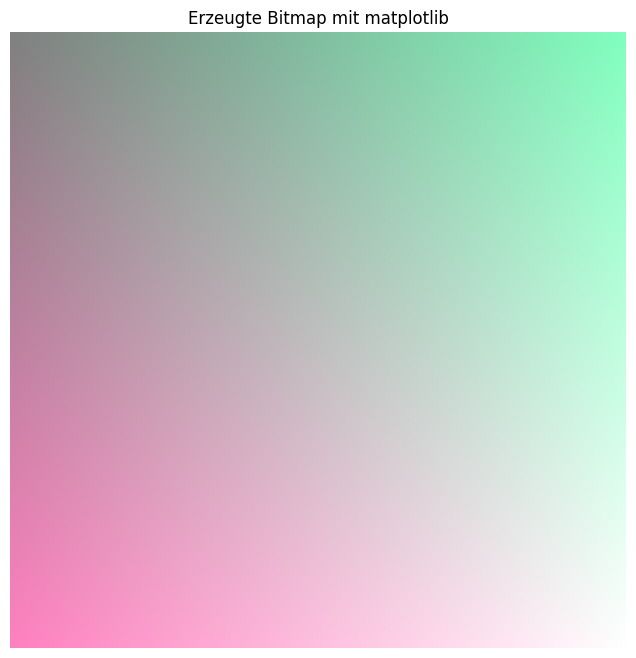

Bitmap wurde erfolgreich als 'bitmap_output.png' gespeichert.


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Erstelle eine einfache Bitmap mit matplotlib
def create_bitmap():
    # Erstelle ein Muster (z.B. ein simples Farbverlaufsmuster)
    width, height = 256, 256
    bitmap = np.zeros((height, width, 4), dtype=np.float32)  # RGBA-Kanäle (4))
    
    # Erstelle einen Farbverlauf
    for i in range(height):
        for j in range(width):
            bitmap[i, j, 0] = i / height  # Rot-Kanal
            bitmap[i, j, 1] = j / width   # Grün-Kanal
            bitmap[i, j, 2] = (i + j) / (height + width)  # Blau-Kanal
            # add a transparency channel
            bitmap[i,j,3] = 0.5  # Alpha-Kanal
    
    # Zeige das Bild an
    plt.figure(figsize=(8, 8))
    plt.imshow(bitmap)
    plt.axis('off')  # Verstecke die Achsen
    plt.title('Erzeugte Bitmap mit matplotlib')
    plt.savefig('bitmap_output.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("Bitmap wurde erfolgreich als 'bitmap_output.png' gespeichert.")

if __name__ == "__main__":
    create_bitmap()